<h1 style="text-align: center;">TUGAS 1 PEMBELAJARAN MESIN</h1>

## Nama : Nailah Zulfa Daaniyah Husen
## NIM  : H081241015
## Kelas: Pembelajaran Mesin B

<h3 style="text-align: center;">Generating Dataset</h3>

In [3]:
!pip install numpy pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install matplotlib seaborn scipy

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.3 MB 2.0 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.3 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.3 MB 1.9 MB/s eta 0:00:04
   ------------- -------------------------- 2.9/8.3 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.3 MB 2.0 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.3 MB 2.1 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.3 MB 2.0 MB/s eta 0:00:03
   ------------------------ --------------- 5.0/8.3 MB 2.1 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 2.1 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.1 MB 2.1 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.1 MB 2.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 2.3 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.1 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 2.1 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.1 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.1 MB 2.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 2.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 2.1 MB/s eta 0:00:02
   -------------------- --


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd

In [7]:
np.random.seed(16)
n = 5500

# 1. Generate Fitur Demografi & Kesehatan Dasar
umur = np.random.randint(18, 64, n)
jenis_kelamin = np.random.choice(['Pria', 'Wanita'], n)
bmi = np.round(np.random.normal(26.5, 6.0, n), 1)
bmi = np.clip(bmi, 15.0, 50.0)
tanggungan = np.random.randint(0, 4, n)
perokok = np.random.choice(['Ya', 'Tidak'], n, p=[0.2, 0.8])
wilayah = np.random.choice(['Kawasan Barat', 'Kawasan Tengah', 'Kawasan Timur'],
    n, p=[0.5, 0.3, 0.2])

# 2. Perhitungan Biaya Klaim
biaya = np.full(n, 15000000.0)
# Faktor Umur
biaya += (umur - 18) * 350000
# Faktor BMI
biaya += np.where(bmi > 25.0, (bmi - 25.0) * 450000, 0)
# Faktor Tanggungan
biaya += tanggungan * 1200000
# Faktor Perokok
biaya += np.where(perokok == 'Ya', 35000000, 0)
# Interaksi Perokok & Obesitas
biaya += np.where((perokok == 'Ya') & (bmi > 30.0), 15000000, 0)
# Faktor Wilayah
biaya = np.where(wilayah == 'Kawasan Timur', biaya * 1.15,
        np.where(wilayah == 'Kawasan Tengah', biaya * 1.05, biaya))
# Noise
noise = np.random.normal(0, 5000000, n)
biaya += noise
# Minimal 3.000.000
biaya = np.maximum(biaya, 3000000)

# 3. Buat DataFrame
df = pd.DataFrame({'Umur': umur,'Jenis_Kelamin': jenis_kelamin,'BMI': bmi,'Tanggungan': tanggungan,'Perokok': perokok,
                   'Wilayah': wilayah,'Biaya_Klaim': np.round(biaya).astype(int)})

# 4. Simpan ke CSV
df.to_csv('data_klaim_kesehatan.csv', index=False)

print("Dataset berhasil dibuat!")
print(df.head())

Dataset berhasil dibuat!
   Umur Jenis_Kelamin   BMI  Tanggungan Perokok         Wilayah  Biaya_Klaim
0    59        Wanita  32.5           0   Tidak   Kawasan Timur     36641727
1    23        Wanita  22.4           0      Ya  Kawasan Tengah     54605412
2    19          Pria  22.2           1   Tidak   Kawasan Barat     18468287
3    22        Wanita  21.9           0   Tidak  Kawasan Tengah     10144420
4    49        Wanita  22.3           3      Ya  Kawasan Tengah     69490643


<h3 style="text-align: center;">A. Analisis Data Eksploratif (EDA)</h3>

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Matplotlib is building the font cache; this may take a moment.


<h3 style="text-align: left;">1. Missing Values</h3>

In [15]:
df = pd.read_csv('data_klaim_kesehatan.csv')
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Umur             0
Jenis_Kelamin    0
BMI              0
Tanggungan       0
Perokok          0
Wilayah          0
Biaya_Klaim      0
dtype: int64

Total missing: 0


<h5 style="text-align: justify;">Hasil pengecekan menunjukkan tidak terdapat missing values pada seluruh variabel (total 0 missing). Hal ini wajar karena dataset merupakan data sintetis yang digenerate secara terprogram. Dalam praktik asuransi nyata, missing values sering terjadi pada variabel seperti BMI (tidak semua nasabah memiliki rekam medis lengkap) atau status perokok di mana nasabah mungkin tidak jujur mengisi formulir. Karena tida ada missing value, dataset siap digunakan tanpa perlu imputasi.</h5>

<h3 style="text-align: left;">2. Outliers</h3>

In [62]:
Q1 = df['Biaya_Klaim'].quantile(0.25)
Q3 = df['Biaya_Klaim'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Biaya_Klaim'] < lower) | (df['Biaya_Klaim'] > upper)]
print(f"Jumlah outlier: {len(outliers)}")
print(f"Batas bawah: Rp {lower:,.0f}")
print(f"Batas atas : Rp {upper:,.0f}")

Jumlah outlier: 699
Batas bawah: Rp -574,080
Batas atas : Rp 63,586,115


<h5 style="text-align: left;">Ditemukan 699 outlier yang seluruhnya berada di atas batas atas Rp 63.586.115. Outlier ini tidak dihapus karena dalam konteks aktuaria, biaya yang tinggi merepresentasikan kasus penyakit kritis nyata yang justru penting untuk pemodelan risiko.</h5>

<h3 style="text-align: left;">3. Visualisasi Distribusi Biaya Klaim</h3>

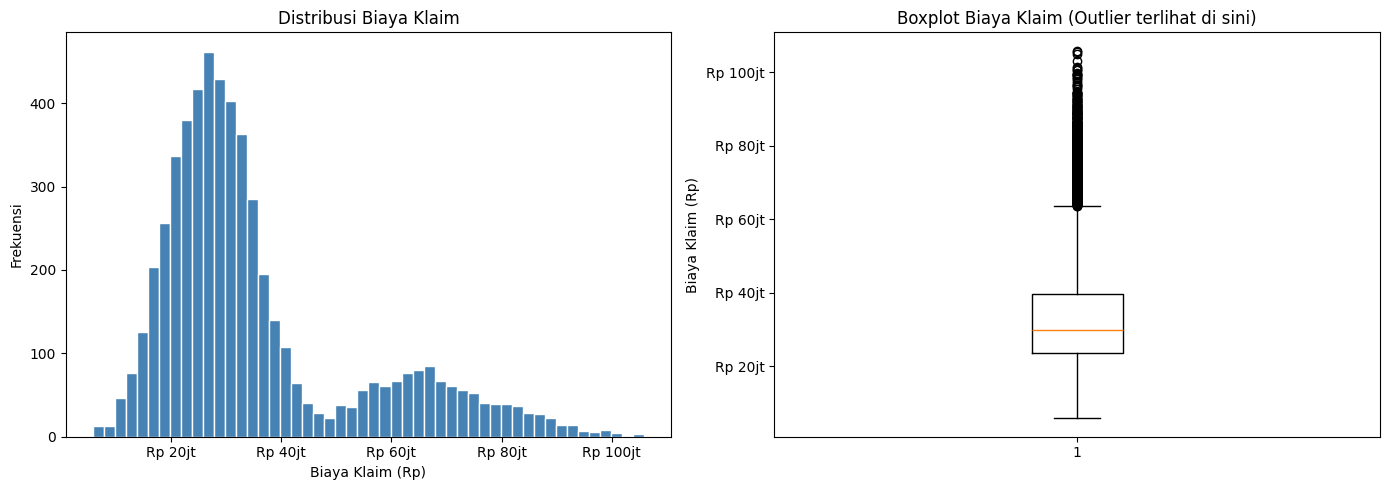

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Biaya_Klaim'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Biaya Klaim')
axes[0].set_xlabel('Biaya Klaim (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}jt'))

# Boxplot
axes[1].boxplot(df['Biaya_Klaim'], vert=True)
axes[1].set_title('Boxplot Biaya Klaim (Outlier terlihat di sini)')
axes[1].set_ylabel('Biaya Klaim (Rp)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}jt'))

plt.tight_layout()
plt.show()

<h5 style="text-align: justify;">Histogram distribusi biaya klaim memperlihatkan pola distribusi yang miring ke kanan, dengan puncak frekuensi terkonsentrasi di kisaran Rp 20-30 juta dan ekor distribusi yang memanjang ke kanan hingga mendekati Rp 100 juta. Pola skewness ini terbentuk karena adanya dua kelompok nasabah yang karakteristiknya berbeda jauh: kelompok non-perokok yang klaimnya relatif moderat di kisaran Rp 20-40 juta, dan kelompok perokok (±20% populasi) yang klaimnya jauh lebih tinggi terutama bila disertai faktor wilayah Timur dan BMI tinggi. Boxplot melengkapi gambaran ini dengan memperlihatkan median klaim sekitar Rp 28-30 juta, IQR antara Rp 18-45 juta, serta banyaknya titik outlier di atas whisker atas yang konsisten dengan temuan 699 outlier sebelumnya. Distribusi yang tidak simetris ini memiliki implikasi aktuaria yang penting: cadangan risiko tidak dapat dihitung sekadar dari rata-rata, melainkan harus mempertimbangkan ekor distribusi yang tebal di sisi kanan.</h5>

<h3 style="text-align: left;">4. Analisis Korelasi</h3>

In [22]:
# Encode variabel kategorikal
df_encoded = df.copy()
df_encoded['Jenis_Kelamin'] = df['Jenis_Kelamin'].map({'Pria': 1, 'Wanita': 0})
df_encoded['Perokok'] = df['Perokok'].map({'Ya': 1, 'Tidak': 0})
df_encoded['Wilayah'] = df['Wilayah'].map({
    'Kawasan Timur': 2, 'Kawasan Tengah': 1, 'Kawasan Barat': 0})

num_df = df_encoded[['Umur', 'BMI', 'Tanggungan', 
                      'Jenis_Kelamin', 'Perokok', 'Wilayah', 'Biaya_Klaim']]

In [24]:
print("Korelasi Pearson vs Biaya Klaim")
print(f"{'Variabel':<15} {'r':>8} {'p-value':>12} {'Keterangan':>15}")
print("-" * 55)
for col in ['Umur', 'BMI', 'Tanggungan', 'Jenis_Kelamin', 'Perokok', 'Wilayah']:
    r, p = stats.pearsonr(num_df[col], num_df['Biaya_Klaim'])
    ket = "Signifikan" if p < 0.05 else "Tidak Signifikan"
    print(f"{col:<15} {r:>8.4f} {p:>12.4f} {ket:>15}")

Korelasi Pearson vs Biaya Klaim
Variabel               r      p-value      Keterangan
-------------------------------------------------------
Umur              0.2502       0.0000      Signifikan
BMI               0.1653       0.0000      Signifikan
Tanggungan        0.0506       0.0002      Signifikan
Jenis_Kelamin     0.0113       0.4025 Tidak Signifikan
Perokok           0.8872       0.0000      Signifikan
Wilayah           0.1132       0.0000      Signifikan


<h5 style="text-align: justify;">Korelasi Pearson mengukur kekuatan hubungan linear antara masing-masing variabel independen terhadap biaya klaim. Hasil analisis menunjukkan bahwa variabel perokok memiliki korelasi tertinggi yang sangat jauh melampaui variabel lain, mengindikasikan bahwa status merokok adalah prediktor utama besarnya klaim kesehatan. Variabel umur menempati posisi kedua yang diikuti BMI, wilayah, dan tanggungan. Keempatnya signifikan secara statistik. Satu-satunya variabel yang tidak signifikan adalah jenis kelamin yang berarti secara statistik tidak terdapat perbedaan biaya klaim yang berarti antara nasabah pria dan wanita dalam dataset ini. Perlu diingat bahwa korelasi Pearson hanya mengukur hubungan linear, sehingga variabel yang memiliki hubungan non-linear dengan biaya klaim seperti umur, kemungkinan nilai korelasinya underestimated oleh metode ini.</h5>

In [25]:
print("\nKorelasi Spearman vs Biaya Klaim")
print(f"{'Variabel':<15} {'r':>8} {'p-value':>12} {'Keterangan':>15}")
print("-" * 55)
for col in ['Umur', 'BMI', 'Tanggungan', 'Jenis_Kelamin', 'Perokok', 'Wilayah']:
    r, p = stats.spearmanr(num_df[col], num_df['Biaya_Klaim'])
    ket = "Signifikan" if p < 0.05 else "Tidak Signifikan"
    print(f"{col:<15} {r:>8.4f} {p:>12.4f} {ket:>15}")


Korelasi Spearman vs Biaya Klaim
Variabel               r      p-value      Keterangan
-------------------------------------------------------
Umur              0.4203       0.0000      Signifikan
BMI               0.1758       0.0000      Signifikan
Tanggungan        0.0918       0.0000      Signifikan
Jenis_Kelamin     0.0120       0.3749 Tidak Signifikan
Perokok           0.6997       0.0000      Signifikan
Wilayah           0.1316       0.0000      Signifikan


<h5 style="text-align: justify;">Korelasi Spearman yang mengukur hubungan monotonic (tidak harus linear) memberikan insight tambahan yang menarik. Variabel Umur menunjukkan peningkatan korelasi yang signifikan dari Pearson 0.2502 menjadi Spearman 0.4203 yang merupakan selisih terbesar di antara semua variabel. Hal ini mengindikasikan bahwa hubungan antara umur dan biaya klaim bersifat monotonic non-linear yang berarti semakin tua, kenaikan biaya klaimnya semakin besar secara akseleratif, bukan linear. Pola ini sangat sesuai dengan tabel mortalitas dalam ilmu aktuaria yang memang 
menunjukkan akselerasi risiko pada usia lanjut. Sebaliknya, korelasi Spearman Perokok (0.6997) lebih rendah dari Pearson (0.8872), karena pengaruh perokok bersifat "lompatan langsung" (diskrit) yang justru lebih tergambar oleh Pearson. Jenis kelamin tetap tidak signifikan di kedua metode, mempertegas bahwa variabel ini tidak layak dijadikan faktor pembeda dalam penetapan premi.</h5>

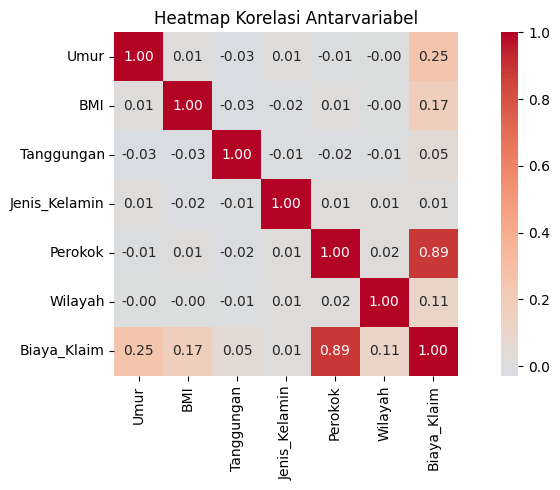

In [27]:
plt.figure(figsize=(9, 5))
sns.heatmap(num_df.corr(method='pearson'),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Heatmap Korelasi Antarvariabel')
plt.tight_layout()
plt.show()

<h5 style="text-align: justify;">Heatmap korelasi Pearson antarvariabel menunjukkan bahwa seluruh pasangan variabel independen memiliki korelasi yang mendekati nol. Hal ini mengkonfirmasi tidak adanya multikolinearitas dalam dataset, yaitu kondisi di mana variabel-variabel independen saling berkorelasi tinggi satu sama lain. Absennya multikolinearitas merupakan kondisi ideal untuk model regresi linear karena koefisien OLS yang dihasilkan akan stabil dan dapat diinterpretasi dengan tepat. Temuan ini juga memberikan petunjuk awal bahwa metode regularisasi seperti Ridge dan Lasso yang utamanya dirancang untuk mengatasi multikolinearitas kemungkinan tidak akan memberikan peningkatan performa yang signifikan dibanding OLS biasa 
pada dataset ini.</h5>

<h3 style="text-align: center;">B. Data Preprocessing</h3>

<h3 style="text-align: left;">1. Encoding (Lanjutan)</h3>

In [29]:
df_processed = df_encoded.copy()

# Tambah One-Hot Encoding untuk Wilayah (ganti encoding angka sebelumnya)
df_processed = df_processed.drop(columns=['Wilayah'])
df_processed = pd.get_dummies(df.copy()[['Wilayah']], columns=['Wilayah'], drop_first=True)
df_processed = pd.concat([df_encoded.drop(columns=['Wilayah']), df_processed], axis=1)

print("Setelah Encoding")
print(df_processed.head())

Setelah Encoding
   Umur  Jenis_Kelamin   BMI  Tanggungan  Perokok  Biaya_Klaim  \
0    59              0  32.5           0        0     36641727   
1    23              0  22.4           0        1     54605412   
2    19              1  22.2           1        0     18468287   
3    22              0  21.9           0        0     10144420   
4    49              0  22.3           3        1     69490643   

   Wilayah_Kawasan Tengah  Wilayah_Kawasan Timur  
0                   False                   True  
1                    True                  False  
2                   False                  False  
3                    True                  False  
4                    True                  False  


<h5 style="text-align: justify;">Tahap encoding bertujuan mengubah variabel kategorikal menjadi representasi numerik agar dapat diproses oleh algoritma regresi. Untuk variabel jenis kelamin dan perokok yang masing-masing hanya memiliki dua kategori, diterapkan label encoding dengan pemetaan Pria=1/Wanita=0 dan Ya=1/Tidak=0. Metode ini tepat untuk variabel biner karena tidak menimbulkan bias urutan yang berarti. Sementara itu, untuk variabel wilayah yang memiliki tiga kategori, diterapkan One-Hot Encoding yang menghasilkan dua kolom dummy baru: Wilayah_Kawasan_Tengah dan Wilayah_Kawasan_Timur, dengan kawasan barat sebagai kategori referensi melalui parameter drop_first=True. Pemilihan One-Hot Encoding untuk wilayah dilakukan karena apabila tiga kategori wilayah dikodekan sebagai 0, 1, 2, model regresi akan mengasumsikan adanya hubungan ordinal yang tidak mencerminkan realita. Dengan One-Hot Encoding, setiap wilayah berdiri independen.</h5>

<h3 style="text-align: left;">2. Feature Scaling</h3>

In [33]:
from sklearn.preprocessing import StandardScaler

X = df_processed.drop(columns=['Biaya_Klaim'])
y = df_processed['Biaya_Klaim']

scaler = StandardScaler()
cols_to_scale = ['Umur', 'BMI', 'Tanggungan']
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("\nSetelah Feature Scaling")
print(X.head())



Setelah Feature Scaling
       Umur  Jenis_Kelamin       BMI  Tanggungan  Perokok  \
0  1.388267              0  1.000580   -1.335425        0   
1 -1.327452              0 -0.707167   -1.335425        1   
2 -1.629198              1 -0.740984   -0.438072        0   
3 -1.402888              0 -0.791709   -1.335425        0   
4  0.633901              0 -0.724076    1.356636        1   

   Wilayah_Kawasan Tengah  Wilayah_Kawasan Timur  
0                   False                   True  
1                    True                  False  
2                   False                  False  
3                    True                  False  
4                    True                  False  


<h5 style="text-align: justify;">Tahap Scaling diterapkan pada tiga variabel numerik kontinu yaitu umur, BMI, dan tanggungan. Proses ini mengubah nilai-nilai tersebut menjadi z-score dengan mean = 0 dan standar deviasi = 1, sehingga seluruh variabel berada dalam skala yang sebanding. Scaling ini tidak diterapkan pada variabel biner maupun variabel dummy wilayah karena sudah berada dalam rentang 0-1. Scaling sangat penting khususnya untuk Ridge dan Lasso Regression. Tanpa scaling, variabel dengan rentang nilai besar akan mendapat penalti regularisasi yang lebih kecil dibanding variabel dengan rentang kecil semata-mata karena perbedaan skala numerik, bukan karena perbedaan kepentingan variabel tersebut. Dengan scaling, penalti λ diterapkan secara adil berdasarkan relevansi setiap variabel terhadap target prediksi.</h5>

<h3 style="text-align: left;">3. Splitting Data</h3>

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Total data   : {len(df)}")
print(f"Training set : {len(X_train)} baris (80%)")
print(f"Test set     : {len(X_test)} baris (20%)")

Total data   : 5500
Training set : 4400 baris (80%)
Test set     : 1100 baris (20%)


<h5 style="text-align: justify;">Dataset dibagi menjadi dua subset menggunakan rasio 80:20. Sebanyak 4.400 baris sebagai training set dan 1.100 baris sebagai test set. Proporsi 80:20 merupakan standar yang umum digunakan dalam machine learning karena menyeimbangkan kebutuhan data yang cukup untuk proses pembelajaran model (4.400 sampel) sekaligus menyediakan data evaluasi yang representatif (1.100 sampel). Dengan asumsi distribusi perokok 
sebesar 20%, test set diperkirakan mengandung sekitar 220 nasabah perokok. Jumlah tersebut cukup memadai untuk mengevaluasi kemampuan model dalam memprediksi klaim dari segmen risiko tinggi ini.</h5>

<h3 style="text-align: center;">C. Pemodelan Regresi</h3>

In [35]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [57]:
from sklearn.linear_model import RidgeCV, LassoCV

<h3 style="text-align: left;">1. Multiple Linear Regression</h3>

In [52]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

print("Model 1: Multiple Linear Regression")
print(f"Intercept : Rp {model_lr.intercept_:,.0f}")
print("\nKoefisien tiap variabel:")
for col, coef in zip(X.columns, model_lr.coef_):
    print(f"  {col:<30} : Rp {coef:>15,.0f}")
print(f"\nMAE  : Rp {mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"RMSE : Rp {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_lr):.4f}")

Model 1: Multiple Linear Regression
Intercept : Rp 25,758,736

Koefisien tiap variabel:
  Umur                           : Rp       4,776,841
  Jenis_Kelamin                  : Rp         -16,180
  BMI                            : Rp       2,987,149
  Tanggungan                     : Rp       1,486,608
  Perokok                        : Rp      41,072,828
  Wilayah_Kawasan Tengah         : Rp       1,752,606
  Wilayah_Kawasan Timur          : Rp       4,743,668

MAE  : Rp 4,850,214
RMSE : Rp 6,055,520
R²   : 0.8941


<h5 style="text-align: justify;">Model Multiple Linear Regression dibangun sebagai baseline dengan menggunakan seluruh variabel yang tersedia. Model menghasilkan intercept sebesar Rp 25.758.736 yang merepresentasikan estimasi biaya dasar nasabah "rata-rata" yaitu wanita non-perokok dengan 
umur, BMI, dan tanggungan rata-rata yang berdomisili di Kawasan Barat. Di antara seluruh koefisien yang dihasilkan, perokok memiliki nilai terbesar yaitu Rp 41.072.828, yang berarti seorang nasabah perokok diperkirakan membayar klaim Rp 41 juta lebih tinggi dibanding non-perokok dengan profil lain yang identik. Umur dan BMI menempati posisi berikutnya, sementara Kawasan Timur memberikan tambahan Rp 4.743.668 dan Kawasan Tengah Rp 1.752.606 dibanding Kawasan Barat sebagai referensi. Sebaliknya, Jenis kelamin menghasilkan koefisien yang sangat kecil dan tidak bermakna, konsisten dengan temuan korelasi sebelumnya. Secara keseluruhan, model baseline ini mencapai R² = 0.8941, artinya 89,41% variasi biaya klaim dalam data dapat dijelaskan oleh keenam variabel independen. Hasil ini menunjukkan performa yang sangat baik untuk data asuransi.</h5>

<h3 style="text-align: left;">2. Ridge Regression</h3>

In [59]:
model_ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0, 260.0, 500.0])
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

print("Model 2: Ridge Regression")
print(f"Lambda optimal (α) : {model_ridge.alpha_}")
print(f"Intercept          : Rp {model_ridge.intercept_:,.0f}")
print("\nKoefisien tiap variabel:")
for col, coef in zip(X.columns, model_ridge.coef_):
    print(f"  {col:<35} : Rp {coef:>15,.0f}")
print(f"\nMAE  : Rp {mean_absolute_error(y_test, y_pred_ridge):,.0f}")
print(f"RMSE : Rp {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_ridge):.4f}")

Model 2: Ridge Regression
Lambda optimal (α) : 0.1
Intercept          : Rp 25,760,142

Koefisien tiap variabel:
  Umur                                : Rp       4,776,718
  Jenis_Kelamin                       : Rp         -16,138
  BMI                                 : Rp       2,987,099
  Tanggungan                          : Rp       1,486,515
  Perokok                             : Rp      41,067,150
  Wilayah_Kawasan Tengah              : Rp       1,752,261
  Wilayah_Kawasan Timur               : Rp       4,742,953

MAE  : Rp 4,850,140
RMSE : Rp 6,055,566
R²   : 0.8941


<h5 style="text-align: justify;">Ridge Regression dijalankan dengan mencari nilai lambda optimal melalui cross-validation dari kandidat alpha [0.1, 1.0, 10.0, 50.0, 100.0, 260.0, 500.0]. Hasil cross-validation memilih alpha optimal sebesar 0.1. Temuan ini memberikan informasi yaitu lambda yang sangat kecil mengindikasikan bahwa penalti regularisasi yang kuat hampir tidak diperlukan untuk data ini. Hal tersebut sepenuhnya konsisten dengan temuan analisis korelasi sebelumnya yang menunjukkan tidak adanya multikolinearitas antar variabel independen, padahal Ridge dirancang utamanya untuk  mengatasi masalah multikolinearitas. Dampaknya, koefisien Ridge hanya mengalami penurunan yang sangat kecil dibanding OLS. Performa model pun hampir identik dengan OLS (R² = 0.8941, MAE Rp 4.849.470), mempertegas bahwa dalam konteks data ini, Ridge tidak memberikan keunggulan prediktif yang berarti dibanding regresi linear biasa.</h5>

<h3 style="text-align: left;">3. Lasso Regression</h3>

In [60]:
model_lasso = LassoCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0, 260.0, 500.0], 
                      max_iter=10000)
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)

print("Model 3: Lasso Regression")
print(f"Lambda optimal (α) : {model_lasso.alpha_}")
print(f"Intercept          : Rp {model_lasso.intercept_:,.0f}")
print("\nKoefisien tiap variabel:")
for col, coef in zip(X.columns, model_lasso.coef_):
    status = "← DIELIMINASI" if coef == 0 else ""
    print(f"  {col:<35} : Rp {coef:>15,.0f} {status}")
print(f"\nMAE  : Rp {mean_absolute_error(y_test, y_pred_lasso):,.0f}")
print(f"RMSE : Rp {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_lasso):.4f}")

Model 3: Lasso Regression
Lambda optimal (α) : 500.0
Intercept          : Rp 25,760,341

Koefisien tiap variabel:
  Umur                                : Rp       4,776,296 
  Jenis_Kelamin                       : Rp         -14,120 
  BMI                                 : Rp       2,986,652 
  Tanggungan                          : Rp       1,486,088 
  Perokok                             : Rp      41,069,842 
  Wilayah_Kawasan Tengah              : Rp       1,748,911 
  Wilayah_Kawasan Timur               : Rp       4,739,253 

MAE  : Rp 4,850,241
RMSE : Rp 6,055,644
R²   : 0.8941


<h5 style="text-align: justify;">Lasso Regression dengan cross-validation memilih lambda optimal sebesar 500.0 yang merupakan nilai terbesar dalam range yang diuji. Berbeda dari ekspektasi umum bahwa Lasso dengan lambda besar akan mengeliminasi beberapa variabel, pada dataset ini seluruh tujuh variabel tetap dipertahankan dalam model dengan koefisien yang tidak nol. Hal ini menunjukkan bahwa semua variabel memiliki kontribusi yang cukup signifikan terhadap prediksi biaya klaim sehingga Lasso tidak membuang satupun. Meski koefisien sedikit mengecil dibanding OLS, performa model secara 
keseluruhan tetap identik (R² = 0.8941). Hasil ini mengkonfirmasi sekali lagi bahwa seluruh variabel dalam dataset ini berkontribusi nyata, dan tidak ada fitur yang redundan untuk dieliminasi.</h5>

<h3 style="text-align: center;">D. Evaluasi Model</h3>

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [42]:
models = {'Linear Regression': y_pred_lr,
    'Ridge Regression' : y_pred_ridge,
    'Lasso Regression' : y_pred_lasso}

print("EVALUASI KETIGA MODEL")
print(f"{'Model':<20} {'MAE':>15} {'RMSE':>15} {'R²':>8}")
print("-" * 62)

for nama, y_pred in models.items():
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"{nama:<20} {mae:>15,.0f} {rmse:>15,.0f} {r2:>8.4f}")

EVALUASI KETIGA MODEL
Model                            MAE            RMSE       R²
--------------------------------------------------------------
Linear Regression          4,850,214       6,055,520   0.8941
Ridge Regression           4,849,470       6,056,015   0.8941
Lasso Regression           4,850,214       6,055,521   0.8941


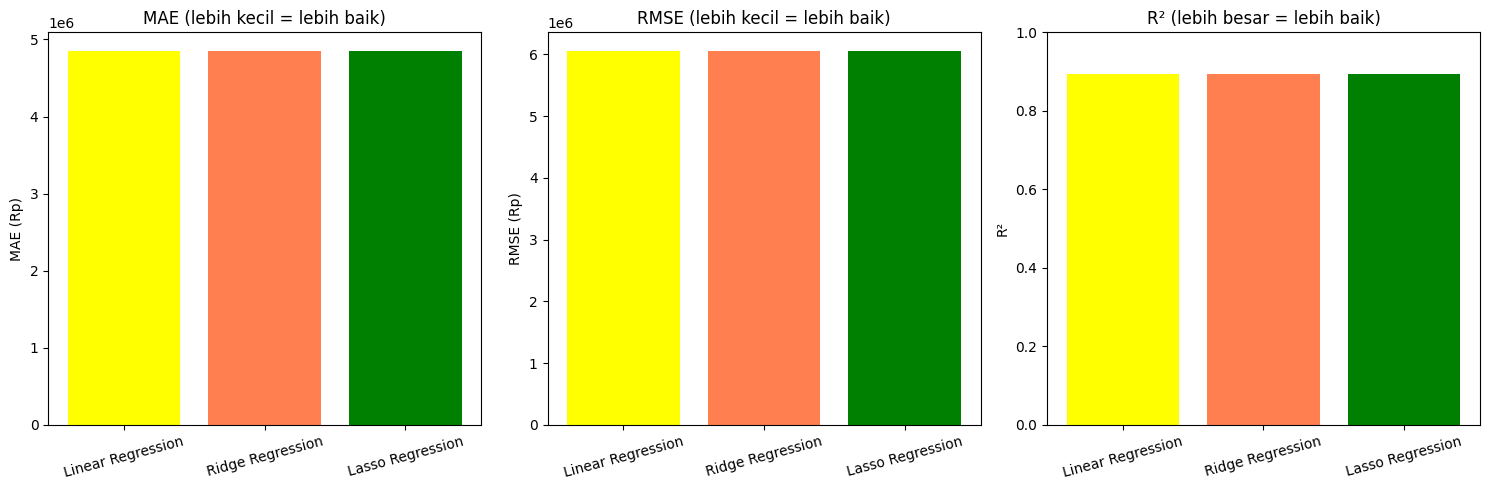

In [49]:
hasil = {'Model': list(models.keys()),
    'MAE'  : [mean_absolute_error(y_test, y_pred) for y_pred in models.values()],
    'RMSE' : [np.sqrt(mean_squared_error(y_test, y_pred)) for y_pred in models.values()],
    'R2'   : [r2_score(y_test, y_pred) for y_pred in models.values()]}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
axes[0].bar(hasil['Model'], hasil['MAE'], color=['yellow', 'coral', 'green'])
axes[0].set_title('MAE (lebih kecil = lebih baik)')
axes[0].set_ylabel('MAE (Rp)')
axes[0].tick_params(axis='x', rotation=15)

# RMSE
axes[1].bar(hasil['Model'], hasil['RMSE'], color=['yellow', 'coral', 'green'])
axes[1].set_title('RMSE (lebih kecil = lebih baik)')
axes[1].set_ylabel('RMSE (Rp)')
axes[1].tick_params(axis='x', rotation=15)

# R²
axes[2].bar(hasil['Model'], hasil['R2'], color=['yellow', 'coral', 'green'])
axes[2].set_title('R² (lebih besar = lebih baik)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

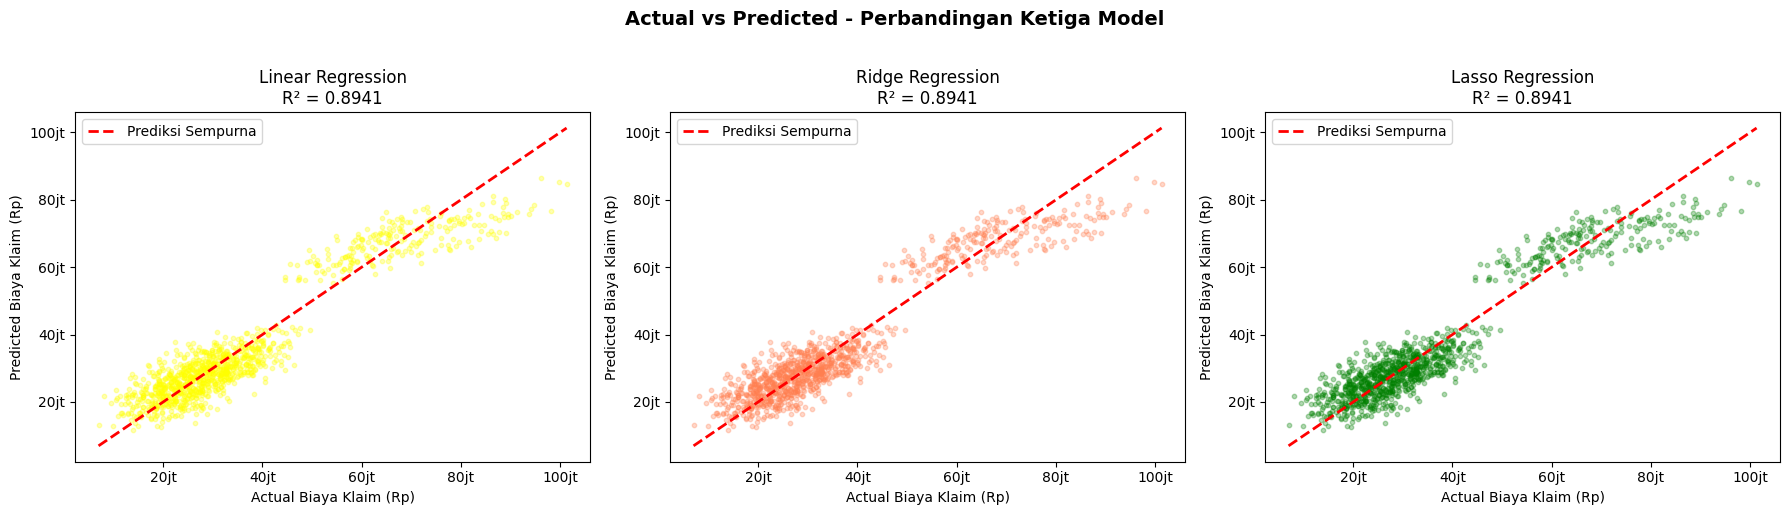

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_plot = {'Linear Regression': y_pred_lr,
    'Ridge Regression' : y_pred_ridge,
    'Lasso Regression' : y_pred_lasso}

colors = ['yellow', 'coral', 'green']

for ax, (nama, y_pred), color in zip(axes, models_plot.items(), colors):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=10)
    
    # Garis sempurna (actual == predicted)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'r--', linewidth=2, label='Prediksi Sempurna')
    
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{nama}\nR² = {r2:.4f}')
    ax.set_xlabel('Actual Biaya Klaim (Rp)')
    ax.set_ylabel('Predicted Biaya Klaim (Rp)')
    ax.legend()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))

plt.suptitle('Actual vs Predicted - Perbandingan Ketiga Model', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<h5 style="text-align: justify;">Perbandingan ketiga model menggunakan tiga metrik standar menunjukkan hasil yang sangat serupa. Linear Regression menghasilkan MAE Rp 4.850.214, RMSE Rp 6.055.520, dan R² 0.8941. Ridge Regression mencatat MAE sedikit lebih rendah yaitu Rp 4.849.470, namun RMSE sedikit lebih tinggi yaitu Rp 6.056.015 dengan R² identik. Lasso Regression menghasilkan metrik yang hampir sama persis dengan Linear Regression. Konvergensi performa ketiga model ini merupakan konsekuensi logis dari tidak adanya multikolinearitas dalam data, kondisi di mana regularisasi Ridge dan Lasso memang tidak akan memberikan keunggulan berarti atas OLS.</h5> 

<h5 style="text-align: justify;">Nilai MAE sebesar Rp 4,85 juta berarti rata-rata prediksi model meleset sekitar Rp 4,85 juta dari biaya klaim aktual. Dalam konteks aktuaria, kesalahan prediksi rata-rata ini masih dalam batas toleransi yang wajar. Yang lebih perlu diperhatikan adalah selisih antara RMSE (Rp 6,05 juta) dan MAE (Rp 4,85 juta) sebesar sekitar Rp 1,2 juta. Gap ini mengindikasikan adanya beberapa prediksi yang meleset cukup jauh dari aktual, terutama pada klaim-klaim besar di atas Rp 70 juta. RMSE yang lebih sensitif terhadap error besar ini mencerminkan kesulitan model dalam memprediksi klaim outlier secara akurat.</h5>

<h5 style="text-align: justify;">Nilai R² = 0.8941 menunjukkan bahwa model mampu menjelaskan 89,41% variasi biaya klaim hanya dari enam variabel profil nasabah. Performa ini tergolong sangat baik, mengingat dalam industri asuransi kesehatan nyata nilai R² di atas 0.70 sudah dianggap memuaskan karena masih banyak faktor risiko yang tidak terobservasi seperti riwayat penyakit keluarga, kepatuhan pengobatan, dan kondisi psikologis nasabah. Sisa 10,59% variasi yang tidak dapat dijelaskan model kemungkinan berasal dari faktor-faktor tersebut.</h5>

<h5 style="text-align: justify;">Plot Actual vs Predicted memperlihatkan bahwa titik-titik prediksi tersebar rapat di sekitar garis prediksi sempurna untuk klaim Rp 20-50 juta, namun deviasi membesar pada klaim di atas Rp 70 juta, menunjukkan kecenderungan model untuk sedikit underestimate klaim yang sangat tinggi. Berdasarkan seluruh pertimbangan ini, model Linear Regression dipilih sebagai model terbaik karena selain performanya kompetitif, koefisiennya dapat diinterpretasi langsung dalam satuan Rupiah yang merupakan properti yang sangat berharga untuk keperluan komunikasi aktuaria kepada manajemen perusahaan asuransi.</h5>

<h3 style="text-align: center;">E. Interpretasi Aktuaria (Business Insight)</h3>

<h5 style="text-align: justify;">Berdasarkan seluruh rangkaian analisis yang telah dilakukan, variabel yang paling berpengaruh terhadap tingginya biaya klaim kesehatan adalah status merokok nasabah. Dengan koefisien model sebesar Rp 41.072.828 dan korelasi Pearson tertinggi (r = 0.8872), perokok terbukti secara statistik membayar klaim jauh lebih tinggi dibanding non-perokok dengan profil identik. Pengaruh ini bahkan semakin besar apabila nasabah perokok juga memiliki BMI di atas 30 (obesitas), di mana terdapat efek interaksi yang menambah biaya klaim sebesar Rp 15.000.000, sehingga total surcharge perokok dengan obesitas mencapai Rp 56 juta di atas nasabah non-perokok normal. Faktor risiko berikutnya adalah umur, yang hubungannya dengan biaya klaim bersifat non-linear akseleratif sebagaimana ditunjukkan oleh korelasi Spearman yang lebih tinggi (0.4203) dibanding Pearson (0.2502) yang menunjukkan semakin tua nasabah, kenaikan risiko kesehatannya semakin cepat, sesuai dengan kurva morbiditas dalam tabel aktuaria. BMI menempati posisi ketiga dengan pengaruh progresif: setiap kenaikan satu unit BMI di atas 25 berkontribusi tambahan biaya klaim yang bermakna. Faktor Wilayah Kawasan Timur juga signifikan, mencerminkan disparitas nyata dalam standar biaya rumah sakit antar wilayah di Indonesia. Satu-satunya variabel yang terbukti tidak berpengaruh adalah jenis kelamin (p = 0.4025), yang berarti penetapan premi berbasis gender tidak dapat dibenarkan secara statistik pada data ini yang juga sejalan dengan prinsip keadilan dalam regulasi asuransi modern.</h5>


<h5 style="text-align: justify;">Sebagai calon aktuaris yang menghadapi pertanyaan penetapan premi bagi nasabah perokok yang berdomisili di Kawasan Timur Indonesia dengan BMI di atas rata-rata, model regresi ini memberikan dasar kuantitatif yang kuat. Nasabah dengan profil tersebut menanggung akumulasi tiga faktor risiko utama secara bersamaan. Sebagai ilustrasi konkret, untuk nasabah berusia 40 tahun dengan BMI 32, status perokok, satu tanggungan, dan domisili di Kawasan Timur, model memprediksi estimasi klaim sebagai berikut: dimulai dari biaya dasar Rp 25.758.736, ditambah faktor umur sekitar Rp 7.700.000, faktor BMI di atas 25 sebesar Rp 3.150.000, faktor tanggungan Rp 1.200.000, surcharge perokok Rp 35.000.000, interaksi perokok-obesitas Rp 15.000.000, yang setelah dikalikan faktor wilayah Timur 1,15 menghasilkan total estimasi klaim sekitar Rp 101-102 juta per tahun. Angka ini menempatkan nasabah tersebut jauh di atas batas outlier Rp 63,5 juta yang telah diidentifikasi sebelumnya.</h5> 

<h5 style="text-align: justify;">Berdasarkan estimasi klaim tersebut, premi murni (pure premium) yang adil secara aktuaria adalah minimal setara estimasi klaim ditambah loading 20-30% untuk biaya operasional dan margin solvabilitas, sehingga premi yang direkomendasikan berkisar Rp 120-135 juta per tahun. Selain penetapan premi, perusahaan asuransi juga perlu membentuk cadangan teknis (technical reserve) yang lebih besar untuk nasabah profil ini, mengingat probabilitas klaim besarnya jauh di atas rata-rata portofolio. Kemudian, perusahaan dapat mempertimbangkan penerapan co-payment untuk mengurangi moral hazard, waiting period untuk kondisi pre-existing, serta program wellness berbasis insentif. Misalnya penurunan premi 20-30% bagi nasabah yang berhasil berhenti merokok atau menurunkan BMI ke rentang normal. Pada tingkat portofolio, manajemen risiko yang bijaksana mengharuskan pembatasan proporsi nasabah profil risiko tinggi ini agar tidak melebihi ambang batas tertentu, serta mempertimbangkan reasuransi untuk klaim yang melampaui Rp 75 juta guna melindungi solvabilitas perusahaan. Dengan demikian, model regresi yang dibangun tidak hanya berfungsi sebagai alat prediksi, tetapi menjadi fondasi pengambilan keputusan aktuaria yang mencakup penetapan premi yang adil (fair pricing), manajemen cadangan yang memadai, dan strategi mitigasi risiko yang komprehensif.</h5>